# S1e. A (128 µm) vs E (64 µm), head to head

The two ends of the FOV axis, run through every downstream step side by side:
featurisation → Leiden → UMAP → tissue maps → cluster composition → border diagnostic.

**Why this pair.** The widest FOV contrast in the sweep, and the place where the
choice of summary statistic matters most. Both statistics agree that A wins — the
question is *by how much*, and that changes the conclusion:

- on the permutation **z-score**, A leads E by 1.6× (23.5 vs 14.7), and E's 14.7 is
  good enough to outrank three other configs in the six-way field;
- on **kappa corrected for grid geometry**, A leads E by ~6× and E finishes last.

E is where z's inflation is largest, because E returns 1078 windows against A's 272.
This notebook shows where that inflation comes from and what the tissue itself says.

| | FOV | pixel_size | global/local | windows | final loss |
|---|---|---|---|---|---|
| **A** | 128 µm | 2.0 | 64 / 48 | 272 | 0.865 |
| **E** | 64 µm | 2.0 | 32 / 24 | 1078 | 2.52 |

64 µm is the practical floor at 2.0 µm/px: the backbone downsamples 16×, so a
32 px global crop leaves a 2×2 pre-pool map and a 24 px local crop leaves 2×2,
while a 16 px input would collapse to 1×1.

For the full six-way comparison see `S1.window_size_sweep.ipynb`; for a single run
in isolation see `S1a.inspect_one_run.ipynb`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import imc_tm

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
pd.set_option("display.width", 250)

PAIR        = ["A_fov128_px2.0", "E_fov64_px2.0"]
RESOLUTION  = 1.0     # Leiden resolution, identical for both
N_NEIGHBORS = 15
SEED        = 0       # pins BOTH the window tiling origin and Leiden
FRACTION    = 0.5     # analysis filter = FRACTION x expected cells for that FOV

print(imc_tm.compat_summary())
print()
for n in PAIR:
    s = imc_tm.sweep_spec(n)
    thr = imc_tm.fov_scaled_threshold(s["fov_um"], fraction=FRACTION)
    ok  = imc_tm.sweep_checkpoint(n).is_file()
    print(f"{n:<16s} FOV {s['fov_um']:3d} um | {s['pixel_size']} um/px | "
          f"global {s['global_size']:3d} / local {s['local_size']:2d} | "
          f"analysis filter {thr:3d} cells | trained: {ok}")

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt

A_fov128_px2.0   FOV 128 um | 2.0 um/px | global  64 / local 48 | analysis filter  52 cells | trained: True
E_fov64_px2.0    FOV  64 um | 2.0 um/px | global  32 / local 24 | analysis filter  13 cells | trained: True


## Loss curves

Both ran the identical 200-epoch schedule. E ends roughly 3× higher, which is the
first hint that its problem is not only one of measurement — the DINO objective on
windows holding ~26 cells is a genuinely harder, noisier target.

Note the plateau to epoch ~100: the LR milestones are `(0, 20, 100, 200)`, so the
peak-LR phase runs to epoch 100 and the cosine decay does the visible work after it.

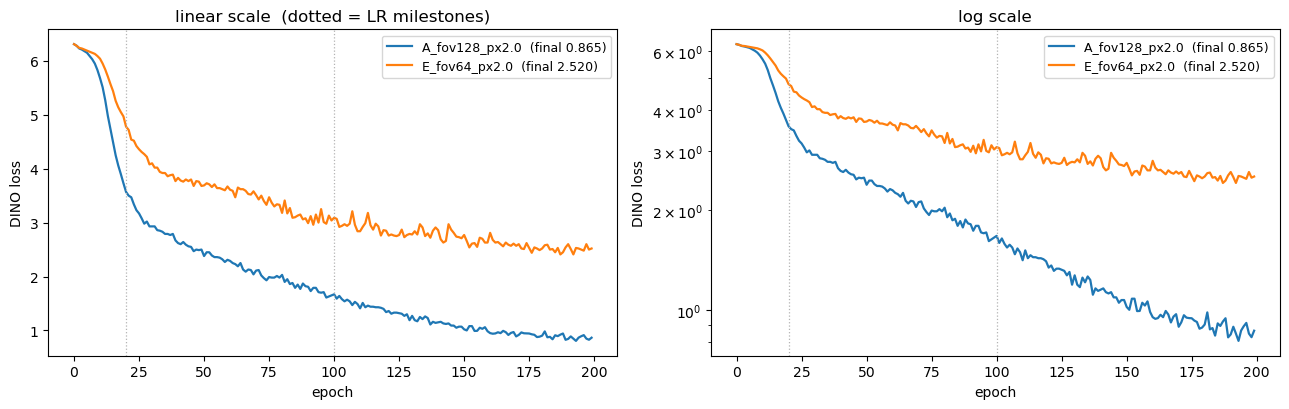

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, logy in zip(axes, [False, True]):
    for n in PAIR:
        lc = imc_tm.read_loss_curve(n)
        if len(lc):
            ax.plot(lc["epoch"], lc["loss"], lw=1.6, label=f"{n}  (final {lc['loss'].iloc[-1]:.3f})")
    ax.axvline(20, color="0.7", lw=0.9, ls=":")
    ax.axvline(100, color="0.7", lw=0.9, ls=":")
    ax.set_xlabel("epoch"); ax.set_ylabel("DINO loss")
    if logy: ax.set_yscale("log"); ax.set_title("log scale")
    else: ax.set_title("linear scale  (dotted = LR milestones)")
    ax.legend(fontsize=9)
plt.tight_layout()

## Featurise

Tiled windows, no overlap, seeded per ROI. The analysis filter scales with FOV
(`imc_tm.fov_scaled_threshold`) so both configs retain the same *tissue coverage* —
52 cells at 128 µm, 13 at 64 µm, both 0.5× the expected count at JHH369 density.

It cannot equalise *count*: a smaller window tiles the same tissue more times, so E
returns ~4× more windows from the same four ROIs. That difference is the whole story
of this notebook.

Slow cell, ~2–4 min.

In [3]:
adatas = imc_tm.load_all_anndata(imc_tm.SWEEP_H5AD_DIR)
ROIS = sorted(adatas)
print("ROIs:", ", ".join(ROIS))

res, clus, thrs = {}, {}, {}
for n in PAIR:
    spec = imc_tm.sweep_spec(n)
    cfg  = imc_tm.sweep_config_dict(spec)
    thrs[n] = imc_tm.fov_scaled_threshold(spec["fov_um"], fraction=FRACTION)
    cfg["n_element_min_for_crop"] = thrs[n]      # ANALYSIS filter, not the training value
    model = imc_tm.load_model(imc_tm.sweep_checkpoint(n))
    dm    = imc_tm.make_datamodule(cfg)
    res[n] = imc_tm.featurize_windows(model, dm, adatas, frac_overlap=0.0, seed=SEED, verbose=False)
    print(f"{n:<16s} {len(res[n]['roi']):5d} windows | feature dim {res[n]['features'].shape[1]}")
    del model, dm

ROIs: JHH369ROI1, JHH369ROI2, JHH369ROI3, JHH369ROI4


[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:34: UnderReviewWarning: The feature generate_power_seq is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  "lr_options": generate_power_seq(LEARNING_RATE_CIFAR, 11),
/home/gavehan/miniforge3/envs/tissue-mosaic-260819/lib/python3.10/site-packages/pl_bolts/models/self_supervised/amdim/amdim_module.py:92: UnderReviewWarning: The feature FeatureMapContrastiveTask is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/sta

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


...

number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 6383
mean and median spacing 7.260443804123195, 6.5180040620742385
The dense shape of the image is -> torch.Size([10, 580, 580])


number of elements ---> 7572
mean and median spacing 6.975763445255431, 6.472262341392154
The dense shape of the image is -> torch.Size([10, 581, 581])


number of elements ---> 8724
mean and median spacing 6.807801972872951, 6.434931372051974
The dense shape of the image is -> torch.Size([10, 580, 581])


E_fov64_px2.0     1078 windows | feature dim 512


## Cluster  *(fast cell — re-run after changing `RESOLUTION`)*

In [4]:
for n in PAIR:
    clus[n] = imc_tm.cluster_embedding(res[n]["features"], n_neighbors=N_NEIGHBORS,
                                       resolution=RESOLUTION, seed=SEED)
    print(f"{n:<16s} {len(np.unique(clus[n]['labels'])):2d} clusters "
          f"from {len(res[n]['roi'])} windows")

# glasbey_dark: at 11 and 15 clusters tab20 wraps into near-duplicate light/dark
# pairs, which made neighbouring clusters indistinguishable in the tissue maps.
COLORS = {n: imc_tm.cluster_palette(labels=sorted(np.unique(clus[n]["labels"]))) for n in PAIR}
print("cluster palette:", imc_tm.cluster_palette_source())

A_fov128_px2.0   11 clusters from 272 windows


E_fov64_px2.0    15 clusters from 1078 windows
cluster palette: colorcet.glasbey_dark


## The headline: how much does A win by?

Three ways of standardising the same quantity — how often neighbouring windows land
in the same cluster, against a within-ROI label permutation.

| | what it divides by | N-dependent? |
|---|---|---|
| `z` | the null's standard deviation | **yes**, grows as ~√N |
| `kappa` | the headroom above chance, `1 − null` | no |
| `kappa_norm` | that config's own **geometric ceiling** | no, and FOV-controlled |

The ceiling is what a *perfect* model would score on that config's actual window
grid: synthetic tissue domains of a fixed physical size, each window labelled by the
domain its centre falls in. Ground truth by construction, so nothing can beat it.

In [5]:
DOMAINS = [400.0, 600.0, 800.0]
rows = []
for n in PAIR:
    m = imc_tm.window_metrics(res[n], clus[n]["labels"], k=4, n_perm=200, seed=SEED)
    row = {"config": n, "FOV_um": imc_tm.sweep_spec(n)["fov_um"], "filter": thrs[n],
           "n_windows": m["n_windows"], "n_clusters": m["n_clusters"],
           "observed": m["spatial_coherence"], "kappa": m["coherence_kappa"],
           "z": m["spatial_coherence_z"], "roi_mixing": m["roi_mixing"],
           "roi_mixing_null": m["roi_mixing_null"],
           "comp_silhouette": m["composition_silhouette"]}
    for D in DOMAINS:
        ceil = imc_tm.coherence_ceiling(res[n]["centers_um"], res[n]["roi"], D)
        row[f"ceil{D:.0f}"] = ceil
        row[f"norm{D:.0f}"] = m["coherence_kappa"] / ceil
    rows.append(row)
met = pd.DataFrame(rows).set_index("config")
display(met.style.format(precision=3))

a, e = PAIR
print(f"\nz         {a}: {met.loc[a,'z']:6.2f}   {e}: {met.loc[e,'z']:6.2f}   "
      f"-> {'E' if met.loc[e,'z'] > met.loc[a,'z'] else 'A'} looks better")
for D in DOMAINS:
    c = f"norm{D:.0f}"
    print(f"norm{D:.0f}   {a}: {met.loc[a,c]:6.2f}   {e}: {met.loc[e,c]:6.2f}   "
          f"-> {'E' if met.loc[e,c] > met.loc[a,c] else 'A'} is better")

,FOV_um,filter,n_windows,n_clusters,observed,kappa,z,roi_mixing,roi_mixing_null,comp_silhouette,ceil400,norm400,ceil600,norm600,ceil800,norm800
config,,,,,,,,,,,,,,,,
A_fov128_px2.0,128,52,272,11,0.528,0.415,23.509,0.650,0.956,-0.028,0.536,0.774,0.652,0.636,0.679,0.611
E_fov64_px2.0,64,13,1078,15,0.179,0.096,14.713,0.898,0.985,-0.087,0.759,0.126,0.825,0.116,0.840,0.114



z         A_fov128_px2.0:  23.51   E_fov64_px2.0:  14.71   -> A looks better
norm400   A_fov128_px2.0:   0.77   E_fov64_px2.0:   0.13   -> A is better
norm600   A_fov128_px2.0:   0.64   E_fov64_px2.0:   0.12   -> A is better
norm800   A_fov128_px2.0:   0.61   E_fov64_px2.0:   0.11   -> A is better


### Why z inflates

`z = (observed − null) / null_sd`, and the null is a permutation distribution whose
spread shrinks as ~1/√n_pairs. Hold the effect size fixed, quadruple the windows, and
z roughly doubles on arithmetic alone.

The cell below demonstrates it on synthetic data with **identical spatial structure**
at two grid sizes, so any difference is purely N.

In [6]:
demo = []
for side in (10, 20, 30):
    g = np.stack(np.meshgrid(np.arange(side), np.arange(side)), -1).reshape(-1, 2).astype(float)
    lab_ = ((g[:, 0] // 3) % 2 + 2 * ((g[:, 1] // 3) % 2)).astype(int)   # same domain size in cells
    sc = imc_tm.spatial_coherence(g, np.array(["R"] * len(g)), lab_, k=4, n_perm=200, seed=0)
    demo.append({"grid": f"{side}x{side}", "N": len(g), "observed": sc["observed"],
                 "null": sc["null_mean"], "kappa": sc["kappa"], "z": sc["z"]})
demo = pd.DataFrame(demo).set_index("grid")
display(demo.style.format(precision=3))
print(f"N x{demo['N'].iloc[-1]/demo['N'].iloc[0]:.0f}  ->  "
      f"z x{demo['z'].iloc[-1]/demo['z'].iloc[0]:.1f}   "
      f"kappa x{demo['kappa'].iloc[-1]/demo['kappa'].iloc[0]:.2f}")

,N,observed,null,kappa,z
grid,,,,,
10x10,100,0.632,0.262,0.502,14.135
20x20,400,0.681,0.252,0.574,27.314
30x30,900,0.691,0.249,0.588,45.334


N x9  ->  z x3.2   kappa x1.17


### Why raw kappa still is not enough

kappa is N-free, but not geometry-free. A 250 µm tissue domain is *one* 192 µm window
and *sixteen* 64 µm windows — so at small FOV neighbouring windows share a domain far
more often, before any model is involved. The ceiling curve below measures exactly
that, and it is the reason `kappa_norm` rather than `kappa` is the comparator.

Where a dashed line sits ABOVE its solid curve, that domain size is too fine to
be the real one -- the model is more spatially coherent than that ground truth.


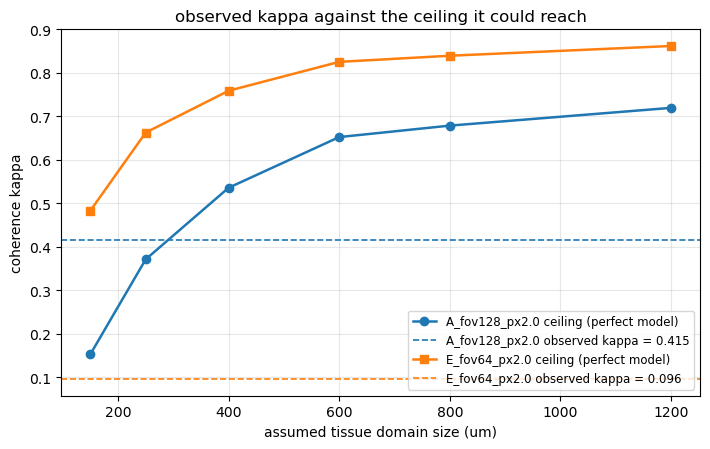

In [7]:
DGRID = [150.0, 250.0, 400.0, 600.0, 800.0, 1200.0]
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for n, style in zip(PAIR, ["-o", "-s"]):
    ceilings = [imc_tm.coherence_ceiling(res[n]["centers_um"], res[n]["roi"], D) for D in DGRID]
    ax.plot(DGRID, ceilings, style, lw=1.8, label=f"{n} ceiling (perfect model)")
    k = met.loc[n, "kappa"]
    ax.axhline(k, ls="--", lw=1.2, color=ax.lines[-1].get_color(),
               label=f"{n} observed kappa = {k:.3f}")
ax.set_xlabel("assumed tissue domain size (um)"); ax.set_ylabel("coherence kappa")
ax.set_title("observed kappa against the ceiling it could reach")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
plt.tight_layout()
print("Where a dashed line sits ABOVE its solid curve, that domain size is too fine to")
print("be the real one -- the model is more spatially coherent than that ground truth.")

## UMAPs

Three colourings each: Leiden cluster, ROI of origin, and dominant biology channel.
The ROI panel is the batch check — structure that tracks ROI rather than biology means
the model has keyed on the section, not the tissue.

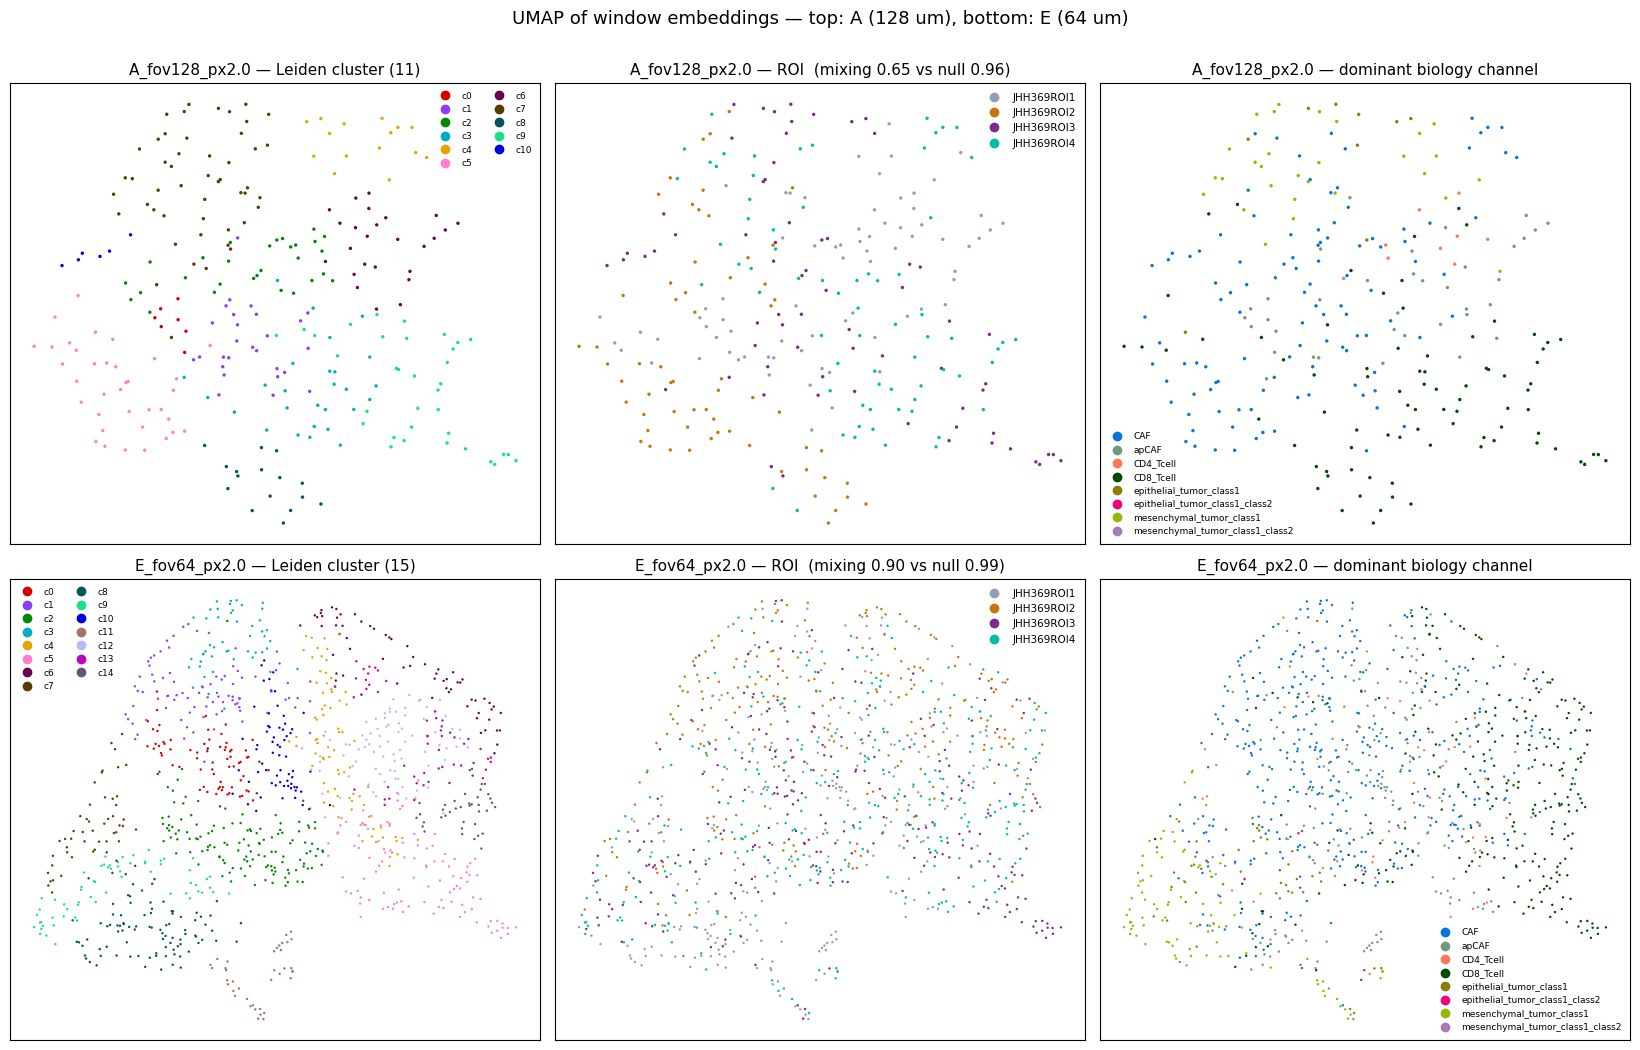

In [8]:
rc = imc_tm.roi_palette(ROIS)      # glasbey_dark, ROI slice
fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.4))
for i, n in enumerate(PAIR):
    u   = clus[n]["umap"]; lab = clus[n]["labels"]
    comp = res[n]["composition"]
    bio_idx = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]
    dom = np.array(imc_tm.BIOLOGY_TYPES)[comp[:, bio_idx].argmax(axis=1)]
    pal = imc_tm.palette()
    s = 6 if len(u) < 500 else 3

    axes[i, 0].scatter(u[:, 0], u[:, 1], c=[COLORS[n][c] for c in lab], s=s, linewidths=0)
    axes[i, 0].set_title(f"{n} — Leiden cluster ({len(np.unique(lab))})", fontsize=11)
    h = [plt.Line2D([0], [0], marker="o", ls="", ms=6, color=COLORS[n][c], label=f"c{c}")
         for c in sorted(np.unique(lab))]
    axes[i, 0].legend(handles=h, fontsize=6.5, ncol=2, loc="best", frameon=False)

    axes[i, 1].scatter(u[:, 0], u[:, 1], color=[rc[r] for r in res[n]["roi"]],
                       s=s, linewidths=0)
    axes[i, 1].set_title(f"{n} — ROI  (mixing {met.loc[n,'roi_mixing']:.2f} "
                         f"vs null {met.loc[n,'roi_mixing_null']:.2f})", fontsize=11)
    h = [plt.Line2D([0], [0], marker="o", ls="", ms=6, color=rc[r], label=r) for r in ROIS]
    axes[i, 1].legend(handles=h, fontsize=7.5, loc="best", frameon=False)

    axes[i, 2].scatter(u[:, 0], u[:, 1], c=[pal[t] for t in dom], s=s, linewidths=0)
    axes[i, 2].set_title(f"{n} — dominant biology channel", fontsize=11)
    h = [plt.Line2D([0], [0], marker="o", ls="", ms=6, color=pal[t], label=t)
         for t in imc_tm.BIOLOGY_TYPES]
    axes[i, 2].legend(handles=h, fontsize=6.5, loc="best", frameon=False)

    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("UMAP of window embeddings — top: A (128 um), bottom: E (64 um)", y=1.005, fontsize=13)
plt.tight_layout()

## Clusters in tissue

The decisive panel. Each square is one window at its true position, **y up**.
Contiguous blocks of one colour mean the window size resolves real tissue domains;
speckle means it does not — and speckle is exactly what a high z with a low kappa
looks like on the tissue.

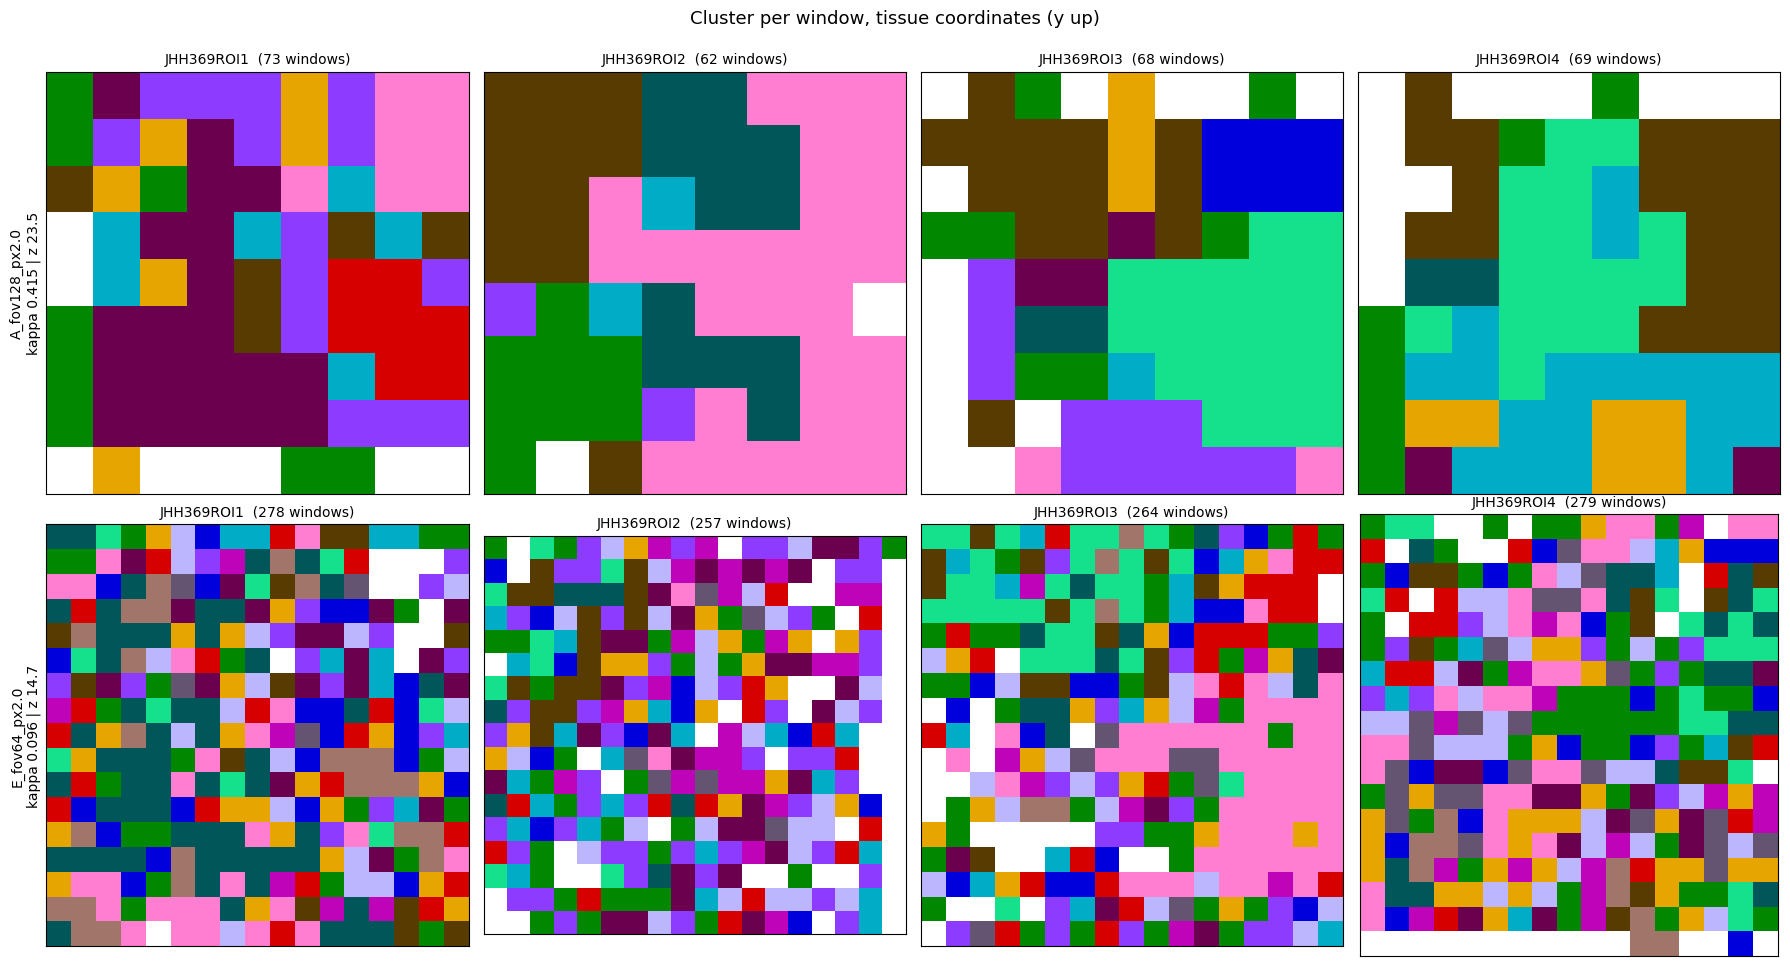

In [9]:
fig, axes = plt.subplots(len(PAIR), len(ROIS), figsize=(4.5 * len(ROIS), 4.8 * len(PAIR)))
axes = np.atleast_2d(axes)
for i, n in enumerate(PAIR):
    lab = clus[n]["labels"]
    fov = imc_tm.sweep_spec(n)["fov_um"]
    for j, r in enumerate(ROIS):
        m = res[n]["roi"] == r
        ax = axes[i, j]
        # true data-coordinate squares, so windows tile without gaps at any figure
        # size -- contiguity is the whole point of this panel
        imc_tm.plot_window_map(ax, res[n]["centers_um"][m], [COLORS[n][c] for c in lab[m]], fov)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{r}  ({m.sum()} windows)", fontsize=10)
    axes[i, 0].set_ylabel(f"{n}\nkappa {met.loc[n,'kappa']:.3f} | z {met.loc[n,'z']:.1f}",
                          fontsize=10)
plt.suptitle("Cluster per window, tissue coordinates (y up)", y=1.002, fontsize=13)
plt.tight_layout()

## What is each cluster made of?

Mean cell-type fraction per cluster; the `ALL` row is the cohort mean, and a cluster
is interesting only where it departs from it.

In [10]:
profs = {}
for n in PAIR:
    comp = pd.DataFrame(res[n]["composition"], columns=imc_tm.CELL_TYPES)
    comp["cluster"] = clus[n]["labels"]
    prof = comp.groupby("cluster")[imc_tm.CELL_TYPES].mean()
    prof.insert(0, "n_windows", comp.groupby("cluster").size())
    prof.loc["ALL"] = [len(comp)] + list(res[n]["composition"].mean(axis=0))
    profs[n] = prof
    print(f"\n=== {n} ===")
    display(prof.round(3).style.background_gradient(axis=0, cmap="Blues",
                                                    subset=imc_tm.CELL_TYPES))


=== A_fov128_px2.0 ===


,n_windows,CAF,apCAF,CD4_Tcell,CD8_Tcell,epithelial_tumor_class1,epithelial_tumor_class1_class2,mesenchymal_tumor_class1,mesenchymal_tumor_class1_class2,other_tissue,duct_filler
cluster,,,,,,,,,,,
0,7.000000,0.073000,0.279000,0.018000,0.023000,0.011000,0.002000,0.002000,0.000000,0.592000,0.000000
1,27.000000,0.109000,0.062000,0.035000,0.082000,0.016000,0.005000,0.007000,0.002000,0.683000,0.000000
2,29.000000,0.101000,0.055000,0.043000,0.058000,0.019000,0.004000,0.011000,0.002000,0.685000,0.023000
3,27.000000,0.063000,0.049000,0.038000,0.080000,0.008000,0.006000,0.004000,0.001000,0.749000,0.002000
4,15.000000,0.074000,0.036000,0.015000,0.037000,0.040000,0.009000,0.104000,0.014000,0.440000,0.231000
5,36.000000,0.072000,0.022000,0.012000,0.052000,0.007000,0.002000,0.002000,0.000000,0.831000,0.000000
6,25.000000,0.073000,0.103000,0.061000,0.061000,0.020000,0.011000,0.040000,0.019000,0.599000,0.014000
7,49.000000,0.064000,0.030000,0.014000,0.017000,0.034000,0.004000,0.079000,0.008000,0.750000,0.000000
8,16.000000,0.079000,0.043000,0.023000,0.168000,0.006000,0.005000,0.000000,0.000000,0.677000,0.000000



=== E_fov64_px2.0 ===


,n_windows,CAF,apCAF,CD4_Tcell,CD8_Tcell,epithelial_tumor_class1,epithelial_tumor_class1_class2,mesenchymal_tumor_class1,mesenchymal_tumor_class1_class2,other_tissue,duct_filler
cluster,,,,,,,,,,,
0,72.000000,0.242000,0.078000,0.024000,0.027000,0.007000,0.005000,0.005000,0.001000,0.611000,0.000000
1,88.000000,0.061000,0.021000,0.016000,0.031000,0.005000,0.000000,0.001000,0.000000,0.865000,0.000000
2,129.000000,0.078000,0.052000,0.027000,0.056000,0.057000,0.016000,0.003000,0.000000,0.711000,0.000000
3,49.000000,0.096000,0.007000,0.005000,0.010000,0.004000,0.000000,0.002000,0.000000,0.875000,0.000000
4,81.000000,0.067000,0.070000,0.059000,0.065000,0.007000,0.003000,0.001000,0.000000,0.728000,0.000000
5,108.000000,0.096000,0.119000,0.089000,0.273000,0.007000,0.009000,0.000000,0.001000,0.405000,0.000000
6,65.000000,0.030000,0.017000,0.009000,0.095000,0.004000,0.003000,0.000000,0.000000,0.842000,0.000000
7,52.000000,0.064000,0.016000,0.009000,0.011000,0.017000,0.003000,0.101000,0.008000,0.765000,0.006000
8,91.000000,0.070000,0.072000,0.047000,0.059000,0.014000,0.008000,0.092000,0.034000,0.597000,0.007000


### The same thing as stacked bars

Left column: all ten channels — `other_tissue` is ~67% of every window and swamps the
stack, which is why the right column drops the two background channels and
renormalises to classified biology.

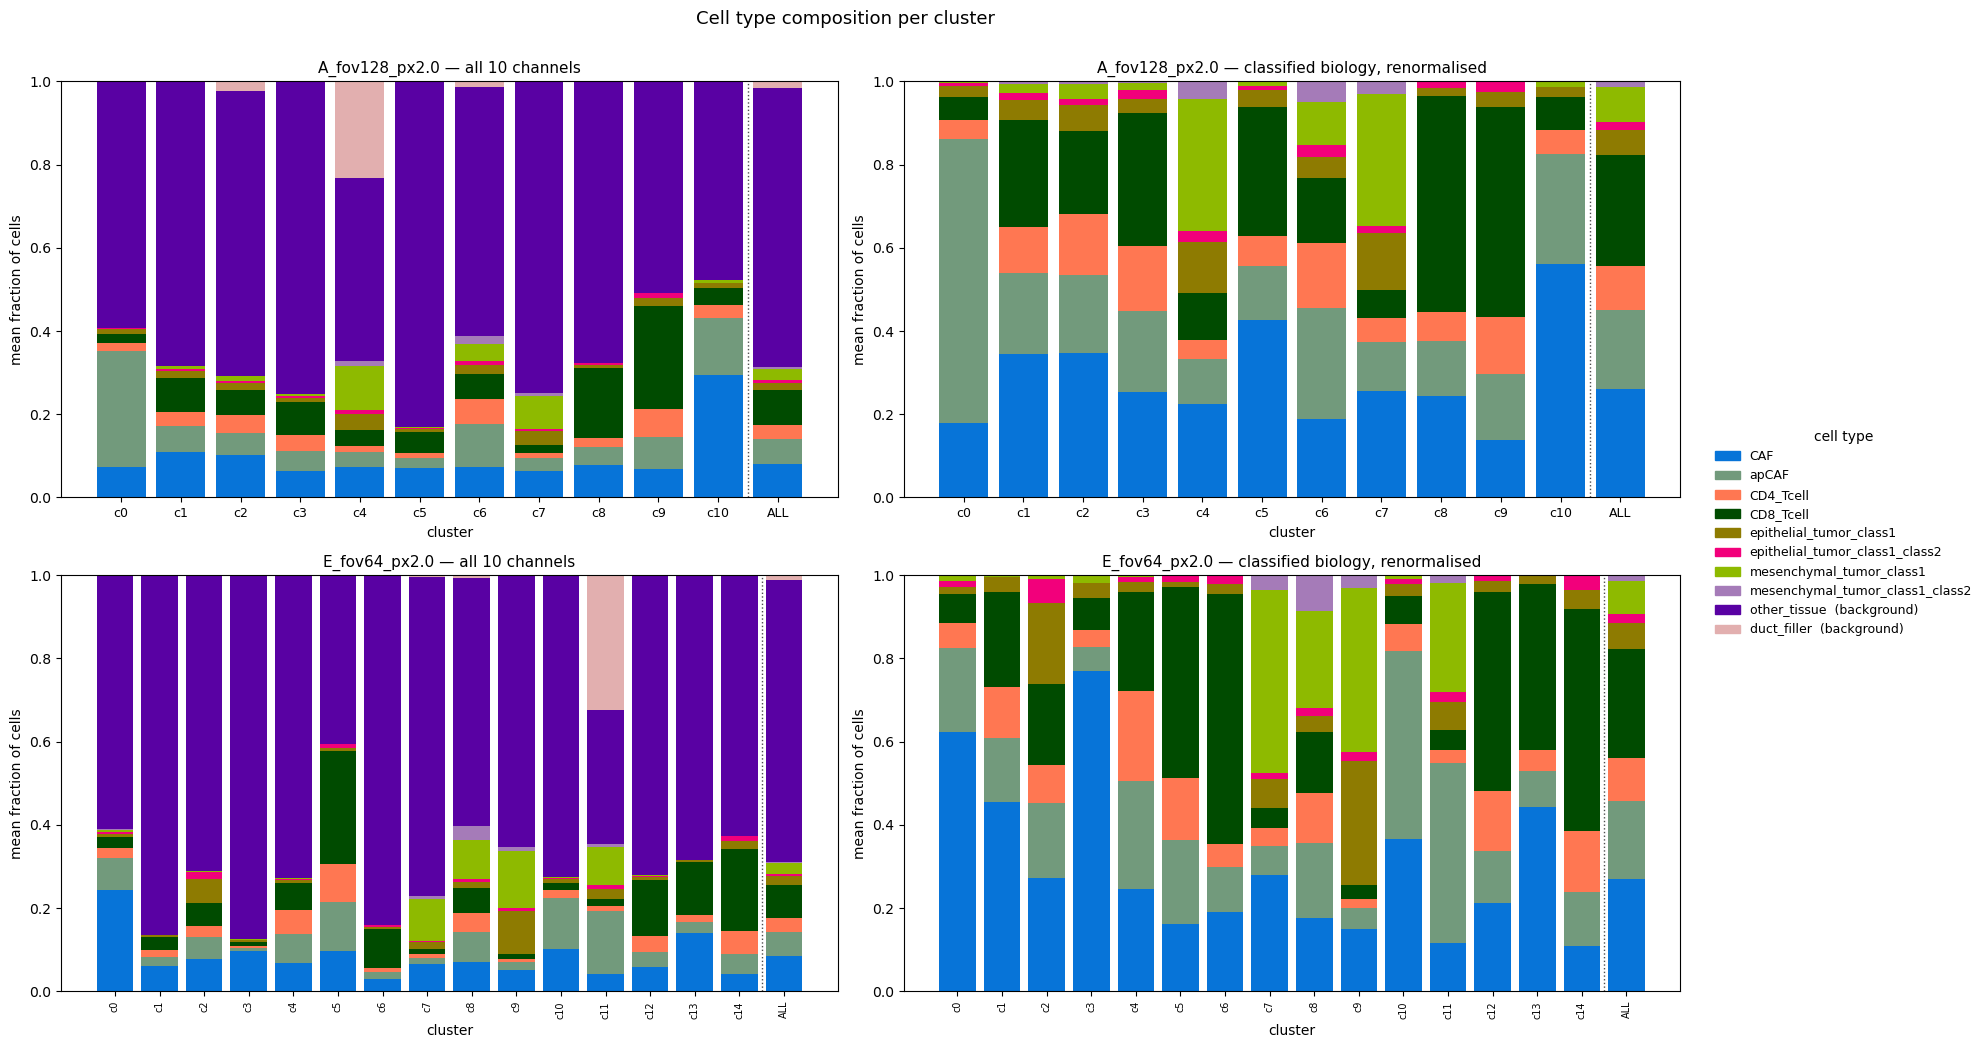

In [11]:
cell_colors = imc_tm.palette()
fig, axes = plt.subplots(len(PAIR), 2, figsize=(17, 5.2 * len(PAIR)))
axes = np.atleast_2d(axes)
for i, n in enumerate(PAIR):
    prof_bar = profs[n].drop(index="ALL")[imc_tm.CELL_TYPES]
    prof_bar.loc["ALL"] = res[n]["composition"].mean(axis=0)
    bio = prof_bar[imc_tm.BIOLOGY_TYPES]
    bio = bio.div(bio.sum(axis=1), axis=0)
    for ax, (tbl, cols, title) in zip(axes[i], [
            (prof_bar, imc_tm.CELL_TYPES, f"{n} — all 10 channels"),
            (bio, imc_tm.BIOLOGY_TYPES, f"{n} — classified biology, renormalised")]):
        bottom = np.zeros(len(tbl)); x = np.arange(len(tbl))
        for t in cols:
            ax.bar(x, tbl[t].values, bottom=bottom, color=cell_colors[t], width=0.82)
            bottom += tbl[t].values
        ax.set_xticks(x)
        ax.set_xticklabels([f"c{k}" if k != "ALL" else "ALL" for k in tbl.index],
                           fontsize=7 if len(tbl) > 12 else 9, rotation=90 if len(tbl) > 12 else 0)
        ax.set_xlabel("cluster"); ax.set_ylabel("mean fraction of cells")
        ax.set_ylim(0, 1); ax.set_title(title, fontsize=11)
        ax.axvline(len(tbl) - 1.5, color="0.3", lw=1, ls=":")
handles = [plt.Rectangle((0, 0), 1, 1, color=cell_colors[t],
                         label=t + ("  (background)" if t in imc_tm.BACKGROUND_TYPES else ""))
           for t in imc_tm.CELL_TYPES]
fig.legend(handles=handles, bbox_to_anchor=(1.005, 0.5), loc="center left",
           fontsize=9, frameon=False, title="cell type")
plt.suptitle("Cell type composition per cluster", y=1.003, fontsize=13)
plt.tight_layout()

### Which ROI does each cluster come from, and what dominates it?

In [12]:
for n in PAIR:
    lab = clus[n]["labels"]
    comp = pd.DataFrame(res[n]["composition"], columns=imc_tm.CELL_TYPES)
    comp["cluster"] = lab
    print(f"\n=== {n} ===")
    ct = pd.crosstab(lab, res[n]["roi"]); ct["total"] = ct.sum(axis=1)
    print(ct.to_string())
    top = comp.groupby("cluster")[imc_tm.BIOLOGY_TYPES].mean().idxmax(axis=1)
    print("dominant BIOLOGY channel per cluster (background excluded):")
    for c, t in top.items():
        frac = comp.groupby("cluster")[t].mean()[c]
        enrich = frac / max(res[n]["composition"][:, imc_tm.CELL_TYPES.index(t)].mean(), 1e-9)
        print(f"  cluster {c:<3} {t:<34s} {frac:.3f}   ({enrich:.1f}x cohort mean)")


=== A_fov128_px2.0 ===
col_0  JHH369ROI1  JHH369ROI2  JHH369ROI3  JHH369ROI4  total
row_0                                                       
0               7           0           0           0      7
1              14           2          11           0     27
2               8           8           7           6     29
3               6           2           1          18     27
4               6           0           3           6     15
5               7          27           2           0     36
6              20           0           3           2     25
7               5          11          14          19     49
8               0          12           2           2     16
9               0           0          19          16     35
10              0           0           6           0      6
dominant BIOLOGY channel per cluster (background excluded):
  cluster 0   apCAF                              0.279   (4.7x cohort mean)
  cluster 1   CAF                              

## Border-cluster diagnostic

The failure seen in v1: windows on the outer ring sit partly outside the tissue, hold
far fewer cells, and can form clusters of their own. Because a border ring is
contiguous by construction, such a cluster *inflates* spatial coherence while carrying
no biology — so a config that produces one is scoring partly on an artefact.

A cluster ≥80% border is the flag.

In [13]:
for n in PAIR:
    df, summary = imc_tm.border_cluster_report(res[n]["centers_um"], res[n]["roi"],
                                               clus[n]["labels"])
    print(f"\n=== {n} ===   overall border {summary['overall_border_pct']}%  |  "
          f"clusters >=80% border: {summary['n_border_clusters_ge80pct']}  |  "
          f"worst cluster {summary['max_cluster_border_pct']:.1f}%")
    print(df.sort_values("pct_border", ascending=False).to_string())


=== A_fov128_px2.0 ===   overall border 33.5%  |  clusters >=80% border: 0  |  worst cluster 62.1%
         n_windows  n_border  pct_border
cluster                                 
2               29        18        62.1
5               36        19        52.8
1               27        12        44.4
7               49        17        34.7
10               6         2        33.3
4               15         5        33.3
0                7         2        28.6
3               27         6        22.2
9               35         5        14.3
8               16         2        12.5
6               25         3        12.0

=== E_fov64_px2.0 ===   overall border 19.5%  |  clusters >=80% border: 0  |  worst cluster 28.6%
         n_windows  n_border  pct_border
cluster                                 
9               63        18        28.6
2              129        34        26.4
1               88        21        23.9
0               72        17        23.6
5              108    

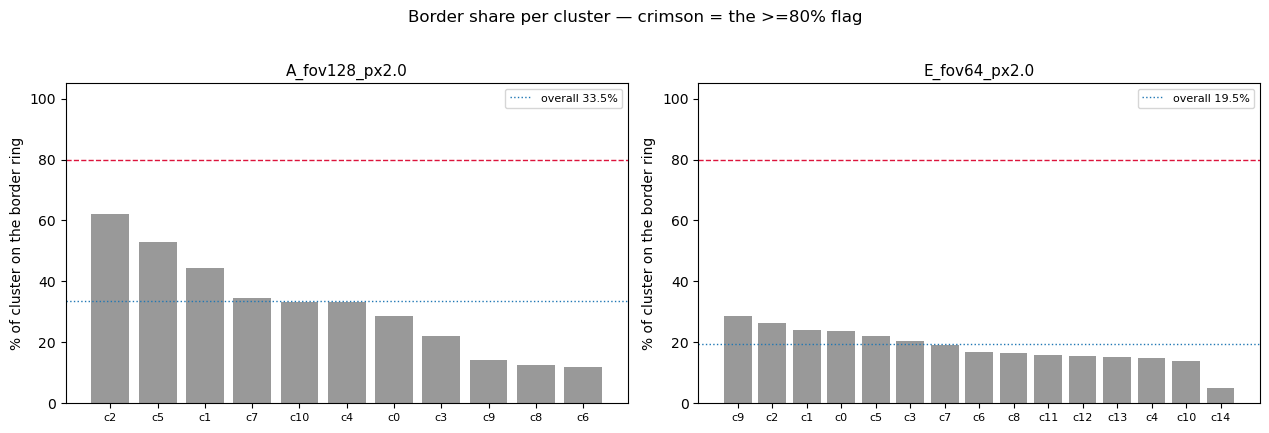

In [14]:
fig, axes = plt.subplots(1, len(PAIR), figsize=(6.4 * len(PAIR), 4.2))
for ax, n in zip(np.atleast_1d(axes), PAIR):
    df, summary = imc_tm.border_cluster_report(res[n]["centers_um"], res[n]["roi"],
                                               clus[n]["labels"])
    df = df.sort_values("pct_border", ascending=False)
    ax.bar(range(len(df)), df["pct_border"].values,
           color=["crimson" if v >= 80 else "0.6" for v in df["pct_border"]])
    ax.axhline(80, color="crimson", lw=1, ls="--")
    ax.axhline(summary["overall_border_pct"], color="C0", lw=1, ls=":",
               label=f"overall {summary['overall_border_pct']}%")
    ax.set_xticks(range(len(df))); ax.set_xticklabels([f"c{i}" for i in df.index], fontsize=8)
    ax.set_ylim(0, 105); ax.set_ylabel("% of cluster on the border ring")
    ax.set_title(f"{n}", fontsize=11); ax.legend(fontsize=8)
plt.suptitle("Border share per cluster — crimson = the >=80% flag", y=1.02, fontsize=12)
plt.tight_layout()

## Does E separate biology more clearly?

Looking at the UMAPs, E's clusters read as crisper and more biologically distinct.
Nothing measured so far actually tests that: `spatial_coherence` asks about spatial
contiguity and `roi_mixing` about batch. So test it directly.

All of this is on **biology-only** composition — background dropped and the rest
renormalised, because `other_tissue` + `duct_filler` are ~71% of every window and
otherwise dominate any distance.

| test | what it asks | depends on Leiden? |
|---|---|---|
| `embed_sil` | how separated are the clusters in embedding space — the UMAP impression | yes |
| `bio_sil` | how separated are they in composition space | yes |
| `knn_r2_bio` | predict a window's composition from its embedding-space neighbours | **no** |
| `mean_max_enrich` | how enriched is each cluster's top cell type | yes |

**N matters for every one of these**, UMAP appearance most of all: E returns 1078
windows to A's 272. So the second table subsamples E to A's N and re-clusters from
scratch, several times.

In [15]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

BIO_IDX = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]
def bio_frac(comp):
    b = np.asarray(comp)[:, BIO_IDX]
    return b / np.clip(b.sum(axis=1, keepdims=True), 1e-9, None)

def knn_r2(feats, target, k=10):
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(feats))).fit(feats)
    pred = target[nn.kneighbors(feats)[1][:, 1:]].mean(axis=1)     # exclude self
    return 1.0 - ((target - pred) ** 2).sum() / ((target - target.mean(axis=0)) ** 2).sum()

def bio_score(feats, comp, labels):
    bf = bio_frac(comp)
    enr = [(bf[labels == c].mean(axis=0) / np.clip(bf.mean(axis=0), 1e-9, None)).max()
           for c in np.unique(labels)]
    return {"n": len(feats), "k_clusters": len(np.unique(labels)),
            "embed_sil": silhouette_score(feats, labels),
            "bio_sil": silhouette_score(bf, labels),
            "knn_r2_bio": knn_r2(feats, bf),
            "mean_max_enrich": float(np.mean(enr)),
            "n_clust_ge2x": int(sum(e >= 2.0 for e in enr))}

asis = pd.DataFrame([{"config": n, **bio_score(res[n]["features"], res[n]["composition"],
                                               clus[n]["labels"])} for n in PAIR]).set_index("config")
print("as-is -- N differs, this is what the UMAP panels above show")
display(asis.style.format(precision=3))

N_TARGET, N_REP = min(len(res[n]["roi"]) for n in PAIR), 8
rows = []
for n in PAIR:
    reps = []
    for rep in range(N_REP):
        sel = np.random.default_rng(100 + rep).choice(len(res[n]["roi"]), N_TARGET, replace=False)
        f, c = res[n]["features"][sel], res[n]["composition"][sel]
        lab_ = imc_tm.cluster_embedding(f, n_neighbors=N_NEIGHBORS, resolution=RESOLUTION,
                                        seed=SEED)["labels"]
        reps.append(bio_score(f, c, lab_))
    rows.append({"config": n, **pd.DataFrame(reps).mean().to_dict()})
matched = pd.DataFrame(rows).set_index("config")
print()
print(f"N matched at {N_TARGET} windows, re-clustered, mean of {N_REP} draws")
display(matched.style.format(precision=3))

as-is -- N differs, this is what the UMAP panels above show


,n,k_clusters,embed_sil,bio_sil,knn_r2_bio,mean_max_enrich,n_clust_ge2x
config,,,,,,,
A_fov128_px2.0,272,11,0.011,-0.095,0.577,2.315,5
E_fov64_px2.0,1078,15,0.029,-0.111,0.615,3.088,12



N matched at 272 windows, re-clustered, mean of 8 draws


,n,k_clusters,embed_sil,bio_sil,knn_r2_bio,mean_max_enrich,n_clust_ge2x
config,,,,,,,
A_fov128_px2.0,272.000,10.375,0.024,-0.095,0.578,2.269,4.625
E_fov64_px2.0,272.000,8.875,0.000,-0.046,0.532,2.667,5.500


### The control that decides it: is the model beating the count vector?

TissueMosaic's claim over a neighbourhood-composition vector is that it encodes
spatial **arrangement**, not just which cell types are present. So throw the model
away, cluster the raw biology-composition vectors directly, and score them the same
way.

If a config's model-embedding clusters are no more spatially coherent than
composition clusters, its SSL added nothing an 8-dimensional count vector did not
already give you — and "separates biology clearly" then means "separates
composition", which is free.

In [16]:
from sklearn.metrics import adjusted_rand_score

rows = []
for n in PAIR:
    variants = {"model embedding": clus[n]["labels"],
                "composition only": imc_tm.cluster_embedding(bio_frac(res[n]["composition"]),
                                                             n_neighbors=N_NEIGHBORS,
                                                             resolution=RESOLUTION, seed=SEED)["labels"]}
    for what, lab_ in variants.items():
        m = imc_tm.window_metrics(res[n], lab_, k=4, n_perm=200, seed=SEED)
        rows.append({"config": n.split("_")[0], "clustered on": what,
                     "n_clusters": m["n_clusters"], "kappa": m["coherence_kappa"],
                     "z": m["spatial_coherence_z"], "roi_mixing": m["roi_mixing"],
                     "norm600": m["coherence_kappa"] / imc_tm.coherence_ceiling(
                         res[n]["centers_um"], res[n]["roi"], 600.0)})
    print(f"{n:<16s} ARI(model clusters, composition clusters) = "
          f"{adjusted_rand_score(variants['model embedding'], variants['composition only']):.3f}")

base = pd.DataFrame(rows).set_index(["config", "clustered on"])
display(base.style.format(precision=3))

print()
print("spatial coherence gained from the model, over clustering composition directly:")
for c in [n.split("_")[0] for n in PAIR]:
    me, co_ = base.loc[(c, "model embedding")], base.loc[(c, "composition only")]
    print(f"  {c}   kappa {co_['kappa']:.3f} -> {me['kappa']:.3f}  "
          f"({100 * (me['kappa'] / max(co_['kappa'], 1e-9) - 1):+.0f}%)   "
          f"roi_mixing {co_['roi_mixing']:.3f} -> {me['roi_mixing']:.3f}")

A_fov128_px2.0   ARI(model clusters, composition clusters) = 0.162


E_fov64_px2.0    ARI(model clusters, composition clusters) = 0.147



spatial coherence gained from the model, over clustering composition directly:
  A   kappa 0.137 -> 0.415  (+203%)   roi_mixing 0.837 -> 0.650
  E   kappa 0.078 -> 0.096  (+23%)   roi_mixing 0.906 -> 0.898


## Reading it

Work through the panels in this order:

1. **Metrics table** — A wins on both statistics, but by 1.6× on z and ~6× on
   `kappa_norm`. The gap between those two numbers is the artefact.
2. **Synthetic demo** — z rises with N at *fixed* structure, kappa does not. That is
   the mechanism, isolated from any real data.
3. **Ceiling curve** — even N-free kappa is not FOV-free, because a fixed physical
   domain spans four times as many windows at 64 µm as at 128 µm.
4. **Tissue maps** — the physical check that does not depend on any statistic. Judge
   contiguity by eye and see which reading it supports.
5. **Composition panels** — E's clusters are *not* noise: they carry real enrichments
   (mesenchymal tumour 5.5×, CD8 3.4×). But they recur in all four ROIs and scatter
   spatially, which is what a 26-cell window gets you — local composition, sampled
   below the scale at which the tissue is organised.
6. **Biology-separation tables** — E does look more biologically separated as
   displayed, and most of that is N: matched to 272 windows, its embedding-space
   separation drops to ~0. What survives is sharper per-cluster enrichment, which a
   26-cell window gets nearly for free.
7. **Composition baseline** — the decisive one. A gains ~200% spatial coherence over
   clustering the count vector; E gains ~20%. E's embedding barely beats an
   8-dimensional summary you can compute without a network. Note also that E's high
   `roi_mixing` sits essentially *on* its composition baseline, so it reflects "did
   not go beyond composition" rather than "found shared motifs".

Two caveats to carry forward:

- **E's high loss (2.52 vs 0.865) is a confound of its own.** A failure to fit and a
  scale mismatch are not separable from this run alone. The composition panels argue
  it is more the latter — E's clusters are compositionally sharp, just spatially
  scattered and ROI-agnostic. Either way 64 µm is not usable under this recipe, which
  is the decision-relevant conclusion.
- **One patient, 200 epochs.** This is a screen, not a converged model. The ranking is
  fair because both configs got an identical schedule; absolute quality is not
  established for either.